# Шаг 1: Установка и настройка Stanza

In [1]:
# Шаг 1: Установка Stanza
!pip install stanza

# Импорт библиотек
import os
import re
import zipfile
import json
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Stanza для морфологического и синтаксического анализа
import stanza

# Скачивание русской модели Stanza
stanza.download('ru')

# Инициализация пайплайна для русского языка
# processors: tokenize, pos, lemma, depparse (для синтаксического анализа)
nlp = stanza.Pipeline('ru', processors='tokenize,pos,lemma,depparse')

print("✅ Stanza настроена и готова к работе")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 23.0 MB/s eta 0:00:00


INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Downloading default packages for language: ru (Russian) ...


models/default.zip: reconstructing file:   0%|          |  0.00B /  629MB            

models/default.zip: downloading bytes:           |  0.00B            

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/ru/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.14.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Loading these models for language: ru (Russian):
| Processor | Package            |
----------------------------------
| tokenize  | syntagrus          |
| pos       | syntagrus_charlm   |
| lemma     | syntagrus_nocharlm |
| depparse  | syntagrus_charlm   |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!


✅ Stanza настроена и готова к работе


# Шаг 2: Импорт библиотек и настройка визуализации

In [2]:
# Шаг 2: Дополнительные импорты и настройки
from scipy import stats
from scipy.stats import chi2_contingency, spearmanr
import math
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('default')
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Библиотеки импортированы")

✅ Библиотеки импортированы


# Шаг 3: Загрузка и распаковка архива

In [3]:
# Шаг 3: Загрузка и распаковка архива
from google.colab import files

print("Загрузите архив chapter_3.zip")
uploaded = files.upload()

# Находим загруженный zip-файл
zip_filename = None
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        zip_filename = filename
        break

if zip_filename:
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print(f"✅ Архив {zip_filename} успешно распакован")

    # Проверяем структуру
    !ls -la /content/chapter_3/
else:
    print("❌ Файл .zip не найден. Пожалуйста, загрузите архив chapter_3.zip")

Загрузите архив chapter_3.zip


Saving chapter_3.zip to chapter_3.zip
✅ Архив chapter_3.zip успешно распакован
total 16
drwxr-xr-x 4 root root 4096 Aug 17 03:46  .
drwxr-xr-x 1 root root 4096 Aug 17 03:46  ..
drwxr-xr-x 2 root root 4096 Aug 17 03:46 'Возвращение Чорба'
drwxr-xr-x 2 root root 4096 Aug 17 03:46  Гроздь


# Шаг 4: Классификация атрибутивных типов с использованием Stanza

In [4]:
# Шаг 4: Классификация атрибутивных типов

class AttributeAnalyzerStanza:
    """
    Анализатор атрибутивных типов с использованием Stanza
    """
    def __init__(self, nlp_pipeline):
        self.nlp = nlp_pipeline
        # UPOS теги в Stanza (Universal POS)
        # ADJ - прилагательное, DET - детерминатив, NOUN - существительное
        # PROPN - имя собственное, ADP - предлог, VERB - глагол
        # PRON - местоимение, AUX - вспомогательный глагол

        # Стоп-слова, которые не считаем атрибутами
        self.stop_words = {'и', 'в', 'на', 'с', 'к', 'у', 'о', 'об', 'от', 'до',
                          'за', 'через', 'по', 'из', 'под', 'над', 'перед', 'для',
                          'же', 'бы', 'ли', 'ведь', 'вон', 'вот', 'даже', 'ещё'}

        # Падежи на русском для Stanza
        self.cases = {
            'nom': 'именительный',
            'gen': 'родительный',
            'dat': 'дательный',
            'acc': 'винительный',
            'ins': 'творительный',
            'prep': 'предложный'
        }

    def process_text(self, text):
        """
        Обработка текста через Stanza
        """
        return self.nlp(text)

    def get_word_features(self, word_data):
        """
        Извлечение признаков слова из результата Stanza
        """
        features = {
            'text': word_data.text,
            'upos': word_data.upos,  # Universal POS
            'xpos': word_data.xpos,  # Fine-grained POS (русский)
            'feats': word_data.feats,  # Морфологические признаки
            'lemma': word_data.lemma,
            'deprel': word_data.deprel,  # Синтаксическая роль
            'head': word_data.head  # Голова в синтаксическом дереве
        }
        return features

    def get_pos(self, word_data):
        """
        Получение части речи слова (Universal POS)
        """
        return word_data.upos

    def get_case(self, word_data):
        """
        Получение падежа слова
        """
        if word_data.feats and 'Case' in word_data.feats:
            return word_data.feats['Case']
        return None

    def is_adjective(self, word_data):
        """
        Проверка, является ли слово прилагательным
        """
        return word_data.upos == 'ADJ'

    def is_adj_pronoun(self, word_data):
        """
        Проверка, является ли слово местоимением-прилагательным
        (в Stanza это DET - детерминатив)
        """
        return word_data.upos == 'DET'

    def is_noun(self, word_data):
        """
        Проверка, является ли слово существительным
        """
        return word_data.upos in ['NOUN', 'PROPN']

    def is_pronoun(self, word_data):
        """
        Проверка, является ли слово местоимением
        """
        return word_data.upos == 'PRON'

    def is_verb(self, word_data):
        """
        Проверка, является ли слово глаголом
        """
        return word_data.upos in ['VERB', 'AUX']

    def is_participle(self, word_data):
        """
        Проверка, является ли слово причастием
        (в русской разметке Stanza это часть xpos)
        """
        if word_data.xpos:
            # PRTF - причастие, PRTS - краткое причастие
            return word_data.xpos in ['PRTF', 'PRTS']
        return False

    def is_preposition(self, word_data):
        """
        Проверка, является ли слово предлогом
        """
        return word_data.upos == 'ADP'

    def is_adverb(self, word_data):
        """
        Проверка, является ли слово наречием
        """
        return word_data.upos == 'ADV'

    def is_attributive(self, word_data, sent, word_idx):
        """
        Определение, является ли слово атрибутом (определением)

        Используется синтаксический анализ Stanza (deprel):
        - amod: прилагательное-определение
        - nmod: существительное-определение
        - det: детерминатив
        - acl: придаточное-определение
        """
        text = word_data.text.lower()
        if text in self.stop_words:
            return None

        deprel = word_data.deprel

        # 1. Прилагательные (amod - adjectival modifier)
        if self.is_adjective(word_data) and deprel == 'amod':
            return 'ПЛ'

        # 2. Местоимения-прилагательные / детерминативы (det)
        if self.is_adj_pronoun(word_data) and deprel == 'det':
            return 'МП'

        # 3. Причастия (acl - clausal modifier)
        if self.is_participle(word_data) and deprel in ['acl', 'amod']:
            return 'ПТ'

        # 4. Генитив (nmod в родительном падеже)
        if self.is_noun(word_data):
            case = self.get_case(word_data)
            if case == 'gen' and deprel == 'nmod':
                return 'ГН'
            # Существительное в косвенном падеже как определение
            if case and case != 'nom' and case != 'acc' and deprel == 'nmod':
                return 'КСВ'

        # 5. Предложные конструкции
        # (определяем по синтаксической связи с существительным)
        if self.is_preposition(word_data):
            # Проверяем, есть ли зависимое существительное
            for child in sent.children[word_data.id]:
                if self.is_noun(child):
                    return 'ПР'

        # 6. Приложения (appos - appositional modifier)
        if deprel == 'appos':
            return 'АП'

        return None

    def get_attributive_type_with_position(self, word_data, sent, word_idx):
        """
        Получение типа атрибута с учетом позиции (пре-/постпозиция)
        """
        base_type = self.is_attributive(word_data, sent, word_idx)
        if not base_type:
            return None

        # Определяем позицию относительно определяемого слова
        # Ищем голову (определяемое слово) в синтаксическом дереве
        head_id = word_data.head
        if head_id and head_id > 0:
            head_word = sent.words[head_id - 1]
            # Если атрибут стоит перед определяемым словом
            if word_data.id < head_word.id:
                position = 'Л'  # Левая позиция (препозиция)
            else:
                position = 'П'  # Правая позиция (постпозиция)
        else:
            # Если не удалось определить голову, проверяем по соседним словам
            position = self._guess_position(sent, word_idx)

        return f"{base_type}-{position}"

    def _guess_position(self, sent, word_idx):
        """
        Вспомогательный метод для определения позиции
        """
        # Проверяем соседние слова справа
        if word_idx < len(sent.words) - 1:
            next_word = sent.words[word_idx]
            if self.is_noun(next_word):
                return 'Л'

        # Проверяем соседние слова слева
        if word_idx > 0:
            prev_word = sent.words[word_idx - 1]
            if self.is_noun(prev_word):
                return 'П'

        return 'П'  # По умолчанию постпозиция

# Инициализация анализатора
analyzer = AttributeAnalyzerStanza(nlp)
print("✅ Анализатор атрибутов инициализирован")

✅ Анализатор атрибутов инициализирован


# Шаг 5: Функция для анализа одного текста с использованием Stanza

In [5]:
# ===================================================================
# ШАГ 5 (ПОЛНОСТЬЮ ПЕРЕПИСАННЫЙ): Анализ одного текста с использованием Stanza
# ===================================================================

def analyze_text_with_stanza(text, analyzer):
    """
    Анализ текста с использованием Stanza

    Возвращает словарь с результатами:
    - total_words: общее количество слов
    - total_attributives: общее количество атрибутов
    - attributives: список атрибутов с типами
    - polyfunctional: список полифункциональных атрибутов
    - abs_counts: абсолютные частоты
    - rel_counts: относительные частоты (на 100 слов)
    """
    # Обработка текста через Stanza
    try:
        doc = analyzer.process_text(text)
    except Exception as e:
        print(f"  ❌ Ошибка Stanza при обработке текста: {e}")
        return None

    # Проверка, есть ли предложения в документе
    if not doc.sentences:
        print(f"  ⚠️ Stanza не нашла предложений в тексте")
        return None

    attributives = []
    total_words = 0

    # Проход по предложениям
    for sent in doc.sentences:
        # Получаем все слова в предложении
        words = sent.words

        # Пропускаем пустые предложения
        if not words:
            continue

        for i, word in enumerate(words):
            # Пропускаем знаки препинания
            if word.upos == 'PUNCT':
                continue

            total_words += 1

            # Получаем тип атрибута с позицией
            try:
                attr_type = analyzer.get_attributive_type_with_position(
                    word, sent, i
                )
            except Exception as e:
                # Если ошибка при определении типа, просто пропускаем слово
                continue

            if attr_type:
                attributives.append({
                    'text': word.text,
                    'type': attr_type,
                    'lemma': word.lemma,
                    'upos': word.upos,
                    'xpos': word.xpos,
                    'deprel': word.deprel,
                    'position': attr_type.split('-')[1] if '-' in attr_type else None,
                    'id': word.id,
                    'head': word.head
                })

    # Проверка, найдены ли слова
    if total_words == 0:
        print(f"  ⚠️ Не найдено слов для анализа")
        return None

    # Подсчет частот
    attr_counts = Counter([attr['type'] for attr in attributives])

    # Расчет относительных частот (на 100 слов)
    rel_counts = {}
    for attr_type, count in attr_counts.items():
        rel_counts[attr_type] = (count / total_words) * 100

    # Добавляем общее количество атрибутов
    rel_counts['Всего'] = (len(attributives) / total_words) * 100

    # Определение полифункциональных атрибутов
    # Полифункциональный атрибут - это атрибут, который сам имеет определения
    polyfunctional = []

    # Создаем множество ID всех атрибутов для быстрой проверки
    attr_ids = {attr['id'] for attr in attributives}

    for attr in attributives:
        # Проверяем, есть ли у этого атрибута зависимые атрибуты
        attr_id = attr['id']
        has_dependent_attrs = False

        for other_attr in attributives:
            # Если другой атрибут ссылается на текущий как на голову
            if other_attr['head'] == attr_id and other_attr['id'] != attr_id:
                has_dependent_attrs = True
                break

        if has_dependent_attrs:
            polyfunctional.append(attr)

    return {
        'total_words': total_words,
        'total_attributives': len(attributives),
        'attributives': attributives,
        'polyfunctional': polyfunctional,
        'abs_counts': dict(attr_counts),
        'rel_counts': rel_counts
    }


def process_file_with_stanza(filepath, analyzer):
    """
    Обработка одного файла

    Возвращает результат анализа или None в случае ошибки
    """
    try:
        # Чтение файла
        with open(filepath, 'r', encoding='utf-8') as f:
            text = f.read()

        # Очистка текста: удаляем лишние пробелы и переносы строк
        text = re.sub(r'\s+', ' ', text).strip()

        # Проверка длины текста
        if len(text) < 10:
            print(f"  ⚠️ Текст слишком короткий (менее 10 символов)")
            return None

        # Проверка наличия русских букв
        if not re.search(r'[а-яА-Я]', text):
            print(f"  ⚠️ В тексте нет русских букв")
            return None

        # Анализ текста
        results = analyze_text_with_stanza(text, analyzer)

        # Проверка результатов
        if results is None:
            print(f"  ⚠️ Анализ текста вернул None")
            return None

        if results['total_words'] == 0:
            print(f"  ⚠️ В тексте не найдено слов")
            return None

        return results

    except UnicodeDecodeError as e:
        print(f"  ❌ Ошибка кодировки файла: {e}")
        return None
    except FileNotFoundError as e:
        print(f"  ❌ Файл не найден: {e}")
        return None
    except Exception as e:
        print(f"  ❌ Неизвестная ошибка при обработке файла: {e}")
        return None


def test_text_analysis():
    """
    Тестовая функция для проверки работы анализатора на коротком тексте
    """
    print("\n" + "="*60)
    print("ТЕСТИРОВАНИЕ АНАЛИЗАТОРА")
    print("="*60)

    test_text = "В осенний день, блистая как стекло, стояла тишина в саду."

    print(f"\nТестовый текст: {test_text}")
    print("\nЗапуск анализа...")

    result = analyze_text_with_stanza(test_text, analyzer)

    if result:
        print(f"\n✅ Анализ успешен!")
        print(f"  Всего слов: {result['total_words']}")
        print(f"  Всего атрибутов: {result['total_attributives']}")
        print(f"\n  Найденные атрибуты:")
        for attr in result['attributives']:
            print(f"    {attr['text']} -> {attr['type']} (deprel: {attr['deprel']})")
        print(f"\n  Относительные частоты:")
        for attr_type, freq in result['rel_counts'].items():
            print(f"    {attr_type}: {freq:.2f}%")
    else:
        print(f"\n❌ Анализ не удался")

    return result


# ===================================================================
# ЗАПУСК ТЕСТА (опционально)
# ===================================================================

# Раскомментируйте следующую строку для тестирования:
# test_result = test_text_analysis()

# Шаг 6: Обработка всех файлов из сборников

In [6]:
# ===================================================================
# ШАГ 6 (ПОЛНОСТЬЮ ПЕРЕПИСАННЫЙ): Обработка всех файлов
# ===================================================================

import os
import re
from collections import Counter

def process_collection_with_stanza(collection_path, analyzer):
    """
    Обработка всех файлов в сборнике с использованием Stanza

    Параметры:
    - collection_path: путь к папке со стихотворениями
    - analyzer: экземпляр класса AttributeAnalyzerStanza

    Возвращает:
    - results: словарь {text_id: result_data}
    """
    results = {}
    all_files = []

    # Проверяем, существует ли путь
    if not os.path.exists(collection_path):
        print(f"❌ Путь не найден: {collection_path}")
        return results

    # Собираем все .txt файлы
    for root, dirs, files in os.walk(collection_path):
        for file in files:
            if file.endswith('.txt'):
                full_path = os.path.join(root, file)
                all_files.append(full_path)

    # Сортируем файлы для воспроизводимости
    all_files.sort()

    collection_name = os.path.basename(collection_path)
    print(f"\n📁 Обработка сборника: {collection_name}")
    print(f"   Найдено файлов: {len(all_files)}")

    # Если файлов нет, выводим содержимое директории
    if len(all_files) == 0:
        print(f"   ⚠️ В сборнике не найдено файлов .txt")
        print(f"   Содержимое директории:")
        for root, dirs, files in os.walk(collection_path):
            if files:
                print(f"     {root}: {files}")
            else:
                print(f"     {root}: (пусто)")
        return results

    # Обрабатываем каждый файл
    for i, filepath in enumerate(all_files):
        filename = os.path.basename(filepath)
        print(f"   [{i+1:2d}/{len(all_files):2d}] {filename[:60]}")

        try:
            result = process_file_with_stanza(filepath, analyzer)

            if result:
                # Извлекаем идентификатор текста
                if '_' in filename:
                    text_id = filename.split('_')[0]
                else:
                    text_id = filename.replace('.txt', '')

                results[text_id] = result
                print(f"    ✅ {result['total_words']} слов, {result['total_attributives']} атрибутов")
            else:
                print(f"    ❌ Ошибка обработки (возвращен None)")

        except Exception as e:
            print(f"    ❌ Исключение при обработке: {str(e)[:100]}")
            continue

    print(f"   ✅ Обработано: {len(results)} текстов из {len(all_files)}")
    return results


def safe_process_file(filepath, analyzer):
    """
    Безопасная обработка одного файла с перехватом всех ошибок

    Возвращает:
    - (result, None) если успешно
    - (None, error_message) если ошибка
    """
    try:
        # Чтение файла
        with open(filepath, 'r', encoding='utf-8') as f:
            text = f.read()

        # Проверка на пустой файл
        if not text:
            return None, "Файл пуст"

        # Очистка текста
        text = re.sub(r'\s+', ' ', text).strip()

        # Проверка длины
        if len(text) < 10:
            return None, f"Текст слишком короткий ({len(text)} символов)"

        # Проверка наличия русских букв
        if not re.search(r'[а-яА-Я]', text):
            return None, "В тексте нет русских букв"

        # Анализ через Stanza
        try:
            result = analyze_text_with_stanza(text, analyzer)

            if result is None:
                return None, "Анализ вернул None"

            if result.get('total_words', 0) == 0:
                return None, "Не найдено слов"

            return result, None

        except Exception as e:
            return None, f"Ошибка Stanza: {str(e)[:100]}"

    except UnicodeDecodeError:
        return None, "Ошибка кодировки (не UTF-8)"
    except FileNotFoundError:
        return None, "Файл не найден"
    except Exception as e:
        return None, f"Ошибка: {str(e)[:100]}"


def process_collection_safe(collection_path, analyzer):
    """
    Безопасная обработка сборника с детальным выводом

    Возвращает:
    - results: словарь {text_id: result_data}
    - errors: список ошибок
    """
    results = {}
    errors = []
    all_files = []

    # Проверка существования пути
    if not os.path.exists(collection_path):
        return results, [f"Путь не найден: {collection_path}"]

    # Сбор всех .txt файлов
    for root, dirs, files in os.walk(collection_path):
        for file in files:
            if file.endswith('.txt'):
                all_files.append(os.path.join(root, file))

    all_files.sort()

    collection_name = os.path.basename(collection_path)
    print(f"\n📁 {collection_name}: {len(all_files)} файлов")

    if len(all_files) == 0:
        print(f"   ⚠️ Файлы .txt не найдены")
        return results, ["Нет файлов .txt"]

    # Обработка каждого файла
    for i, filepath in enumerate(all_files):
        filename = os.path.basename(filepath)
        print(f"  [{i+1:3d}/{len(all_files):3d}] {filename[:55]}")

        result, error = safe_process_file(filepath, analyzer)

        if result:
            # Извлекаем ID текста
            if '_' in filename:
                text_id = filename.split('_')[0]
            else:
                text_id = filename.replace('.txt', '')

            results[text_id] = result
            print(f"    ✅ слов: {result['total_words']:4d}, атрибутов: {result['total_attributives']:3d}")
        else:
            errors.append(f"{filename}: {error}")
            print(f"    ❌ {error}")

    print(f"  Итого: {len(results)} успешно, {len(errors)} ошибок")
    return results, errors


def get_collection_stats(results, collection_name):
    """
    Получение статистики по обработанному сборнику
    """
    if not results:
        return None

    total_words = sum(r['total_words'] for r in results.values())
    total_attrs = sum(r['total_attributives'] for r in results.values())

    stats = {
        'collection': collection_name,
        'texts': len(results),
        'total_words': total_words,
        'total_attrs': total_attrs,
        'avg_words': total_words / len(results),
        'avg_attrs': total_attrs / len(results),
        'attr_density': (total_attrs / total_words) * 100 if total_words > 0 else 0
    }

    return stats


def print_collection_summary(groz_results, vozv_results):
    """
    Вывод сводной статистики по сборникам
    """
    print("\n" + "="*70)
    print("СВОДНАЯ СТАТИСТИКА ПО СБОРНИКАМ")
    print("="*70)

    groz_stats = get_collection_stats(groz_results, 'Гроздь')
    vozv_stats = get_collection_stats(vozv_results, 'Возвращение Чорба')

    print(f"\n{'Параметр':<30} {'Гроздь':<20} {'Возвращение Чорба':<20}")
    print("-"*70)

    if groz_stats and vozv_stats:
        print(f"{'Количество текстов':<30} {groz_stats['texts']:<20} {vozv_stats['texts']:<20}")
        print(f"{'Всего слов':<30} {groz_stats['total_words']:<20} {vozv_stats['total_words']:<20}")
        print(f"{'Всего атрибутов':<30} {groz_stats['total_attrs']:<20} {vozv_stats['total_attrs']:<20}")
        print(f"{'Средняя плотность атрибутов':<30} {groz_stats['attr_density']:.2f}%{'':<16} {vozv_stats['attr_density']:.2f}%")
    else:
        if not groz_stats:
            print(f"{'Гроздь':<30} {'Нет данных':<20}")
        if not vozv_stats:
            print(f"{'Возвращение Чорба':<30} {'Нет данных':<20}")


# ===================================================================
# ЗАПУСК ОБРАБОТКИ
# ===================================================================

def run_collection_processing():
    """
    Главная функция для запуска обработки сборников
    """
    print("="*70)
    print("ЗАПУСК ОБРАБОТКИ СБОРНИКОВ")
    print("="*70)

    # Проверка структуры директорий
    base_path = '/content/chapter_3'

    print(f"\n🔍 Проверка директории: {base_path}")

    if not os.path.exists(base_path):
        print(f"❌ Директория {base_path} не найдена!")
        print("\n📂 Содержимое /content:")
        for item in os.listdir('/content'):
            item_path = os.path.join('/content', item)
            if os.path.isdir(item_path):
                print(f"  📁 {item}")
                # Показываем содержимое поддиректорий
                try:
                    subitems = os.listdir(item_path)
                    for sub in subitems[:5]:
                        print(f"    📄 {sub}")
                    if len(subitems) > 5:
                        print(f"    ... и еще {len(subitems)-5} файлов")
                except:
                    pass
            else:
                print(f"  📄 {item}")

        print("\n⚠️ Убедитесь, что архив chapter_3.zip правильно загружен и распакован.")
        print("   Загрузите файл через Шаг 3 (Загрузка и распаковка архива).")
        return None, None

    print(f"✅ Директория {base_path} существует")

    # Проверяем наличие поддиректорий
    groz_path = os.path.join(base_path, 'Гроздь')
    vozv_path = os.path.join(base_path, 'Возвращение Чорба')

    if os.path.exists(groz_path):
        groz_files = [f for f in os.listdir(groz_path) if f.endswith('.txt')]
        print(f"  📁 Гроздь: {len(groz_files)} файлов .txt")
    else:
        print(f"  ❌ Гроздь: папка не найдена")
        return None, None

    if os.path.exists(vozv_path):
        vozv_files = [f for f in os.listdir(vozv_path) if f.endswith('.txt')]
        print(f"  📁 Возвращение Чорба: {len(vozv_files)} файлов .txt")
    else:
        print(f"  ❌ Возвращение Чорба: папка не найдена")
        return None, None

    # Обработка сборников
    print("\n" + "-"*70)
    print("НАЧАЛО ОБРАБОТКИ")
    print("-"*70)

    groz_results, groz_errors = process_collection_safe(groz_path, analyzer)
    vozv_results, vozv_errors = process_collection_safe(vozv_path, analyzer)

    # Вывод итогов
    print("\n" + "-"*70)
    print("ИТОГИ ОБРАБОТКИ")
    print("-"*70)
    print(f"\n  «Гроздь»: {len(groz_results)} текстов, {len(groz_errors)} ошибок")
    print(f"  «Возвращение Чорба»: {len(vozv_results)} текстов, {len(vozv_errors)} ошибок")

    if groz_errors:
        print(f"\n  Ошибки в «Гроздь» (первые 5):")
        for err in groz_errors[:5]:
            print(f"    ⚠️ {err}")

    if vozv_errors:
        print(f"\n  Ошибки в «Возвращение Чорба» (первые 5):")
        for err in vozv_errors[:5]:
            print(f"    ⚠️ {err}")

    # Вывод сводной статистики
    print_collection_summary(groz_results, vozv_results)

    return groz_results, vozv_results


# ===================================================================
# ВЫПОЛНЕНИЕ
# ===================================================================

# Запуск обработки
groz_results, vozv_results = run_collection_processing()

# Сохраняем результаты в глобальные переменные для доступа из других шагов
if groz_results and vozv_results:
    print("\n✅ Результаты сохранены в переменные:")
    print(f"  groz_results: {len(groz_results)} текстов")
    print(f"  vozv_results: {len(vozv_results)} текстов")
else:
    print("\n❌ Обработка завершилась с ошибками. Проверьте сообщения выше.")

ЗАПУСК ОБРАБОТКИ СБОРНИКОВ

🔍 Проверка директории: /content/chapter_3
✅ Директория /content/chapter_3 существует
  📁 Гроздь: 38 файлов .txt
  📁 Возвращение Чорба: 24 файлов .txt

----------------------------------------------------------------------
НАЧАЛО ОБРАБОТКИ
----------------------------------------------------------------------

📁 Гроздь: 38 файлов
  [  1/ 38] ГР-1.txt
    ✅ слов:  294, атрибутов:  45
  [  2/ 38] ГР-10.txt
    ✅ слов:   74, атрибутов:   8
  [  3/ 38] ГР-11.txt
    ✅ слов:   96, атрибутов:  10
  [  4/ 38] ГР-12.txt
    ✅ слов:   84, атрибутов:   7
  [  5/ 38] ГР-13.txt
    ✅ слов:  110, атрибутов:  21
  [  6/ 38] ГР-14.txt
    ✅ слов:   79, атрибутов:  12
  [  7/ 38] ГР-15.txt
    ✅ слов:   81, атрибутов:  11
  [  8/ 38] ГР-16.txt
    ✅ слов:  103, атрибутов:  12
  [  9/ 38] ГР-17.txt
    ✅ слов:   93, атрибутов:  14
  [ 10/ 38] ГР-18.txt
    ✅ слов:   70, атрибутов:   6
  [ 11/ 38] ГР-19.txt
    ✅ слов:   82, атрибутов:  10
  [ 12/ 38] ГР-2.txt
    ✅ слов:  209

# Шаг 7: Создание сводных таблиц

In [7]:
# Шаг 7: Создание сводных таблиц

def create_summary_table(results, collection_name):
    """
    Создание сводной таблицы с частотами атрибутивных типов
    """
    # Все возможные типы атрибутов
    all_types = ['ПЛ', 'МП', 'ГН', 'ПР', 'ПТ', 'ПРД', 'НЧ', 'АП', 'КСВ', 'Всего']

    data = []
    for text_id, result in results.items():
        row = {'Текст': text_id}
        rel_counts = result['rel_counts']

        for attr_type in all_types:
            row[attr_type] = rel_counts.get(attr_type, 0.0)

        data.append(row)

    df = pd.DataFrame(data)

    # Добавляем итоговую строку со средними значениями
    means = df[all_types].mean()
    means['Текст'] = 'СРЕДНЕЕ'
    df = pd.concat([df, pd.DataFrame([means])], ignore_index=True)

    return df

# Создаем таблицы
df_groz = create_summary_table(groz_results, 'Гроздь')
df_vozv = create_summary_table(vozv_results, 'Возвращение Чорба')

print("📊 Таблица для сборника 'Гроздь':")
display(df_groz.head(10))

print("\n📊 Таблица для сборника 'Возвращение Чорба':")
display(df_vozv.head(10))

📊 Таблица для сборника 'Гроздь':


,Текст,ПЛ,МП,ГН,ПР,ПТ,ПРД,НЧ,АП,КСВ,Всего
0,ГР-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.306122
1,ГР-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.810811
2,ГР-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.416667
3,ГР-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.333333
4,ГР-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.090909
5,ГР-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.189873
6,ГР-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.580247
7,ГР-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.650485
8,ГР-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.053763
9,ГР-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.571429



📊 Таблица для сборника 'Возвращение Чорба':


,Текст,ПЛ,МП,ГН,ПР,ПТ,ПРД,НЧ,АП,КСВ,Всего
0,ВЧ-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.465116
1,ВЧ-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.786260
2,ВЧ-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.108108
3,ВЧ-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.447761
4,ВЧ-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.688312
5,ВЧ-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.102564
6,ВЧ-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.166667
7,ВЧ-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.317073
8,ВЧ-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.538462
9,ВЧ-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.244898


# Шаг 8: Расчет статистических показателей

In [8]:
# Шаг 8: Расчет статистических показателей

def calculate_statistics(df, collection_name):
    """
    Расчет статистических показателей для сборника
    """
    # Исключаем строку со средним
    df_clean = df[df['Текст'] != 'СРЕДНЕЕ']

    # Исключаем колонку 'Текст'
    attr_cols = [col for col in df_clean.columns if col != 'Текст']

    stats = {}
    for col in attr_cols:
        values = df_clean[col].values
        mean = np.mean(values)
        std = np.std(values, ddof=1)  # Выборочное стандартное отклонение
        cv = (std / mean) * 100 if mean > 0 else 0
        min_val = np.min(values)
        max_val = np.max(values)

        stats[col] = {
            'mean': mean,
            'std': std,
            'cv': cv,
            'min': min_val,
            'max': max_val
        }

    return pd.DataFrame(stats).T

# Расчет статистик
stats_groz = calculate_statistics(df_groz, 'Гроздь')
stats_vozv = calculate_statistics(df_vozv, 'Возвращение Чорба')

print("📊 Статистика для 'Гроздь':")
display(stats_groz)

print("\n📊 Статистика для 'Возвращение Чорба':")
display(stats_vozv)

📊 Статистика для 'Гроздь':


,mean,std,cv,min,max
ПЛ,0.000000,0.0000,0.000000,0.0,0.000000
МП,0.000000,0.0000,0.000000,0.0,0.000000
ГН,0.000000,0.0000,0.000000,0.0,0.000000
ПР,0.000000,0.0000,0.000000,0.0,0.000000
ПТ,0.000000,0.0000,0.000000,0.0,0.000000
ПРД,0.000000,0.0000,0.000000,0.0,0.000000
НЧ,0.000000,0.0000,0.000000,0.0,0.000000
АП,0.000000,0.0000,0.000000,0.0,0.000000
КСВ,0.000000,0.0000,0.000000,0.0,0.000000
Всего,12.699372,3.7588,29.598313,2.0,19.090909



📊 Статистика для 'Возвращение Чорба':


,mean,std,cv,min,max
ПЛ,0.000000,0.000000,0.00000,0.000000,0.000000
МП,0.000000,0.000000,0.00000,0.000000,0.000000
ГН,0.000000,0.000000,0.00000,0.000000,0.000000
ПР,0.000000,0.000000,0.00000,0.000000,0.000000
ПТ,0.000000,0.000000,0.00000,0.000000,0.000000
ПРД,0.000000,0.000000,0.00000,0.000000,0.000000
НЧ,0.000000,0.000000,0.00000,0.000000,0.000000
АП,0.000000,0.000000,0.00000,0.000000,0.000000
КСВ,0.000000,0.000000,0.00000,0.000000,0.000000
Всего,10.811698,3.492448,32.30249,5.833333,18.918919


# Шаг 9: Расчет индекса Хирша (h-индекса)

In [9]:
# Шаг 9: Расчет h-индекса

def calculate_h_index(df, collection_name):
    """
    Расчет h-индекса для распределения атрибутов
    """
    # Исключаем строку со средним
    df_clean = df[df['Текст'] != 'СРЕДНЕЕ']

    # Сортируем по частоте "Всего" в порядке убывания
    sorted_df = df_clean.sort_values('Всего', ascending=False).reset_index(drop=True)

    # Добавляем ранг (начиная с 1)
    sorted_df['Ранг'] = sorted_df.index + 1

    # Находим h-индекс
    h_index = 0
    for i, row in sorted_df.iterrows():
        rank = row['Ранг']
        freq = row['Всего']
        if freq >= rank:
            h_index = rank
        else:
            break

    print(f"\n{'='*50}")
    print(f"СБОРНИК: {collection_name}")
    print(f"{'='*50}")
    print(f"h-индекс (точка Хирша) = {h_index}")

    # Показываем топ-текстов
    print(f"\nТоп-{h_index} текстов по плотности атрибутов:")
    display(sorted_df[['Текст', 'Всего', 'Ранг']].head(h_index))

    # Расчет индекса концентрации
    # (формула из монографии)
    if h_index > 0:
        top_texts = sorted_df.head(h_index)
        h_value = h_index
        total_freq = sorted_df['Всего'].sum()

        # Расчет концентрации
        concentration = 0
        for i, row in top_texts.iterrows():
            rank = row['Ранг']
            freq = row['Всего']
            concentration += (h_value - rank) * freq

        denominator = h_value * (h_value - 1) * sorted_df.iloc[0]['Всего']
        if denominator > 0:
            concentration_index = 2 * concentration / denominator
        else:
            concentration_index = 0

        print(f"\nИндекс концентрации: {concentration_index:.4f}")
    else:
        concentration_index = 0

    return sorted_df, h_index, concentration_index

# Расчет h-индекса
sorted_groz, h_groz, conc_groz = calculate_h_index(df_groz, 'Гроздь')
sorted_vozv, h_vozv, conc_vozv = calculate_h_index(df_vozv, 'Возвращение Чорба')


СБОРНИК: Гроздь
h-индекс (точка Хирша) = 13

Топ-13 текстов по плотности атрибутов:


,Текст,Всего,Ранг
0,ГР-13,19.090909,1
1,ГР-3,18.681319,2
2,ГР-29,18.055556,3
3,ГР-22,17.857143,4
4,ГР-2,17.224880,5
5,ГР-6,16.981132,6
6,ГР-20,16.513761,7
7,ГР-21,15.966387,8
8,ГР-27,15.476190,9
9,ГР-1,15.306122,10



Индекс концентрации: 0.9165

СБОРНИК: Возвращение Чорба
h-индекс (точка Хирша) = 11

Топ-11 текстов по плотности атрибутов:


,Текст,Всего,Ранг
0,ВЧ-22,18.918919,1
1,ВЧ-5,16.470588,2
2,ВЧ-9,15.277778,3
3,ВЧ-6,14.583333,4
4,ВЧ-14,14.102564,5
5,ВЧ-24,13.157895,6
6,ВЧ-10,12.786260,7
7,ВЧ-18,12.244898,8
8,ВЧ-13,11.688312,9
9,ВЧ-2,11.578947,10



Индекс концентрации: 0.8024


# Шаг 10: Расчет коэффициента Бузмана и соотношения АТ

In [10]:
# Шаг 10: Соотношение адъективных и субстантивных атрибутов

def calculate_buzeman_ratio(df, collection_name):
    """
    Расчет коэффициента Бузмана для соотношения
    адъективных и субстантивных атрибутов
    """
    # Исключаем строку со средним
    df_clean = df[df['Текст'] != 'СРЕДНЕЕ']

    results = []
    for _, row in df_clean.iterrows():
        text_id = row['Текст']

        # Адъективные атрибуты: ПЛ, МП
        adj_count = row.get('ПЛ', 0) + row.get('МП', 0)

        # Субстантивные: ГН, ПР, АП, КСВ
        subst_count = row.get('ГН', 0) + row.get('ПР', 0) + row.get('АП', 0) + row.get('КСВ', 0)

        total = adj_count + subst_count

        # Коэффициент Бузмана
        if total > 0:
            b = adj_count / total
        else:
            b = 0.5

        # Расчет критерия Хи-квадрат
        if total > 0:
            chi2 = ((adj_count - subst_count) ** 2) / total
        else:
            chi2 = 0

        # Определение типа преобладания
        if b > 0.59:
            dominance = 'АДК'  # Адъективный
        elif b < 0.41:
            dominance = 'СУБ'  # Субстантивный
        else:
            dominance = 'НТР'  # Нейтральный

        # Статистическая значимость (при уровне α=0.05)
        significant = chi2 > 3.84

        results.append({
            'Текст': text_id,
            'Адъективные': adj_count,
            'Субстантивные': subst_count,
            'Всего': total,
            'Коэф. Бузмана': b,
            'Хи-квадрат': chi2,
            'Преобладание': dominance,
            'Значимо': significant
        })

    df_ratio = pd.DataFrame(results)

    # Статистика по сборнику
    mean_b = df_ratio['Коэф. Бузмана'].mean()
    adj_dominant = len(df_ratio[df_ratio['Преобладание'] == 'АДК'])
    neutral = len(df_ratio[df_ratio['Преобладание'] == 'НТР'])
    subst_dominant = len(df_ratio[df_ratio['Преобладание'] == 'СУБ'])

    print(f"\n{'='*50}")
    print(f"СБОРНИК: {collection_name}")
    print(f"{'='*50}")
    print(f"Средний коэффициент Бузмана: {mean_b:.3f}")
    print(f"Тексты с преобладанием АДК: {adj_dominant}")
    print(f"Тексты с нейтрализацией: {neutral}")
    print(f"Тексты с преобладанием СУБ: {subst_dominant}")

    return df_ratio, mean_b

# Расчет соотношений
ratio_groz, mean_b_groz = calculate_buzeman_ratio(df_groz, 'Гроздь')
ratio_vozv, mean_b_vozv = calculate_buzeman_ratio(df_vozv, 'Возвращение Чорба')

print("\n📊 Детальные результаты для 'Гроздь':")
display(ratio_groz.head(10))

print("\n📊 Детальные результаты для 'Возвращение Чорба':")
display(ratio_vozv.head(10))


СБОРНИК: Гроздь
Средний коэффициент Бузмана: 0.500
Тексты с преобладанием АДК: 0
Тексты с нейтрализацией: 38
Тексты с преобладанием СУБ: 0

СБОРНИК: Возвращение Чорба
Средний коэффициент Бузмана: 0.500
Тексты с преобладанием АДК: 0
Тексты с нейтрализацией: 24
Тексты с преобладанием СУБ: 0

📊 Детальные результаты для 'Гроздь':


,Текст,Адъективные,Субстантивные,Всего,Коэф. Бузмана,Хи-квадрат,Преобладание,Значимо
0,ГР-1,0.0,0.0,0.0,0.5,0,НТР,False
1,ГР-10,0.0,0.0,0.0,0.5,0,НТР,False
2,ГР-11,0.0,0.0,0.0,0.5,0,НТР,False
3,ГР-12,0.0,0.0,0.0,0.5,0,НТР,False
4,ГР-13,0.0,0.0,0.0,0.5,0,НТР,False
5,ГР-14,0.0,0.0,0.0,0.5,0,НТР,False
6,ГР-15,0.0,0.0,0.0,0.5,0,НТР,False
7,ГР-16,0.0,0.0,0.0,0.5,0,НТР,False
8,ГР-17,0.0,0.0,0.0,0.5,0,НТР,False
9,ГР-18,0.0,0.0,0.0,0.5,0,НТР,False



📊 Детальные результаты для 'Возвращение Чорба':


,Текст,Адъективные,Субстантивные,Всего,Коэф. Бузмана,Хи-квадрат,Преобладание,Значимо
0,ВЧ-1,0.0,0.0,0.0,0.5,0,НТР,False
1,ВЧ-10,0.0,0.0,0.0,0.5,0,НТР,False
2,ВЧ-11,0.0,0.0,0.0,0.5,0,НТР,False
3,ВЧ-12,0.0,0.0,0.0,0.5,0,НТР,False
4,ВЧ-13,0.0,0.0,0.0,0.5,0,НТР,False
5,ВЧ-14,0.0,0.0,0.0,0.5,0,НТР,False
6,ВЧ-15,0.0,0.0,0.0,0.5,0,НТР,False
7,ВЧ-16,0.0,0.0,0.0,0.5,0,НТР,False
8,ВЧ-17,0.0,0.0,0.0,0.5,0,НТР,False
9,ВЧ-18,0.0,0.0,0.0,0.5,0,НТР,False


# Шаг 11: Анализ синтаксической инверсии

In [11]:
# Шаг 11: Анализ синтаксической инверсии

def analyze_inversion(results, collection_name):
    """
    Анализ синтаксической инверсии атрибутов
    """
    # Типы с инверсией: ПЛ-П, МП-П, ГН-Л, ПР-Л, ПТ-П
    inversion_types = ['ПЛ-П', 'МП-П', 'ГН-Л', 'ПР-Л', 'ПТ-П']

    data = []
    for text_id, result in results.items():
        rel_counts = result['rel_counts']

        # Общее количество атрибутов
        total_attrs = result['total_attributives']
        total_words = result['total_words']

        # Количество инвертированных
        inv_count = sum(rel_counts.get(attr_type, 0) for attr_type in inversion_types)
        inv_percent = (inv_count / total_attrs) * 100 if total_attrs > 0 else 0
        inv_per_100 = (inv_count / total_words) * 100 if total_words > 0 else 0

        row = {
            'Текст': text_id,
            'Всего_АТ': total_attrs,
            'Инвертированные_АТ': inv_count,
            'Инверсия_%': inv_percent,
            'Инверсия_на_100': inv_per_100
        }

        # Добавляем частоты по типам
        for inv_type in inversion_types:
            row[inv_type] = rel_counts.get(inv_type, 0)

        data.append(row)

    df_inv = pd.DataFrame(data)

    # Статистика по сборнику
    print(f"\n{'='*50}")
    print(f"СБОРНИК: {collection_name}")
    print(f"{'='*50}")
    print(f"Средний процент инверсии: {df_inv['Инверсия_%'].mean():.2f}%")
    print(f"Среднее количество инверсий на 100 слов: {df_inv['Инверсия_на_100'].mean():.2f}")

    # Распределение по типам
    print("\nРаспределение инверсии по типам (% от всех инверсий):")
    total_inv = df_inv['Инвертированные_АТ'].sum()
    for inv_type in inversion_types:
        type_sum = df_inv[inv_type].sum()
        pct = (type_sum / total_inv) * 100 if total_inv > 0 else 0
        print(f"  {inv_type}: {pct:.1f}%")

    return df_inv

# Анализ инверсии
inv_groz = analyze_inversion(groz_results, 'Гроздь')
inv_vozv = analyze_inversion(vozv_results, 'Возвращение Чорба')

print("\n📊 Детальные результаты для 'Гроздь':")
display(inv_groz.head(10))

print("\n📊 Детальные результаты для 'Возвращение Чорба':")
display(inv_vozv.head(10))


СБОРНИК: Гроздь
Средний процент инверсии: 17.77%
Среднее количество инверсий на 100 слов: 2.31

Распределение инверсии по типам (% от всех инверсий):
  ПЛ-П: 67.2%
  МП-П: 32.8%
  ГН-Л: 0.0%
  ПР-Л: 0.0%
  ПТ-П: 0.0%

СБОРНИК: Возвращение Чорба
Средний процент инверсии: 18.10%
Среднее количество инверсий на 100 слов: 2.10

Распределение инверсии по типам (% от всех инверсий):
  ПЛ-П: 75.2%
  МП-П: 24.8%
  ГН-Л: 0.0%
  ПР-Л: 0.0%
  ПТ-П: 0.0%

📊 Детальные результаты для 'Гроздь':


,Текст,Всего_АТ,Инвертированные_АТ,Инверсия_%,Инверсия_на_100,ПЛ-П,МП-П,ГН-Л,ПР-Л,ПТ-П
0,ГР-1,45,2.721088,6.046863,0.925540,2.380952,0.340136,0,0,0
1,ГР-10,8,1.351351,16.891892,1.826150,1.351351,0.000000,0,0,0
2,ГР-11,10,1.041667,10.416667,1.085069,1.041667,0.000000,0,0,0
3,ГР-12,7,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
4,ГР-13,21,3.636364,17.316017,3.305785,3.636364,0.000000,0,0,0
5,ГР-14,12,1.265823,10.548523,1.602307,0.000000,1.265823,0,0,0
6,ГР-15,11,2.469136,22.446689,3.048316,1.234568,1.234568,0,0,0
7,ГР-16,12,5.825243,48.543689,5.655575,4.854369,0.970874,0,0,0
8,ГР-17,14,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
9,ГР-18,6,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0



📊 Детальные результаты для 'Возвращение Чорба':


,Текст,Всего_АТ,Инвертированные_АТ,Инверсия_%,Инверсия_на_100,ПЛ-П,МП-П,ГН-Л,ПР-Л,ПТ-П
0,ВЧ-1,9,2.325581,25.839793,2.704164,2.325581,0.000000,0,0,0
1,ВЧ-10,67,2.671756,3.987695,0.509877,1.526718,1.145038,0,0,0
2,ВЧ-11,6,1.351351,22.522523,1.826150,1.351351,0.000000,0,0,0
3,ВЧ-12,7,1.492537,21.321962,2.227668,1.492537,0.000000,0,0,0
4,ВЧ-13,18,1.948052,10.822511,1.264969,1.948052,0.000000,0,0,0
5,ВЧ-14,11,1.282051,11.655012,1.643655,0.000000,1.282051,0,0,0
6,ВЧ-15,11,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
7,ВЧ-16,9,1.626016,18.066847,1.321964,0.813008,0.813008,0,0,0
8,ВЧ-17,9,1.282051,14.245014,1.643655,1.282051,0.000000,0,0,0
9,ВЧ-18,12,2.040816,17.006803,2.082466,2.040816,0.000000,0,0,0


# Шаг 12: Анализ полифункциональных атрибутов

In [12]:
# Шаг 12: Анализ полифункциональных атрибутов

def analyze_polyfunctional(results, collection_name):
    """
    Анализ полифункциональных атрибутов (ПФА)
    """
    data = []

    for text_id, result in results.items():
        total_attrs = result['total_attributives']

        # Получаем полифункциональные атрибуты
        polyfunctional = result.get('polyfunctional', [])
        poly_count = len(polyfunctional)

        # Процент ПФА от всех атрибутов
        poly_percent = (poly_count / total_attrs) * 100 if total_attrs > 0 else 0

        # Анализ валентности ПФА
        valencies = {}
        for attr in polyfunctional:
            # Подсчет валентности (количество собственных определений)
            val = 1  # Минимальная валентность
            # Реальная валентность вычисляется на основе синтаксического дерева
            # (упрощенно: проверяем наличие зависимых определений)
            valencies[val] = valencies.get(val, 0) + 1

        data.append({
            'Текст': text_id,
            'Всего_АТ': total_attrs,
            'ПФА': poly_count,
            'ПФА_%': poly_percent,
            'Валентности': valencies
        })

    df_poly = pd.DataFrame(data)

    # Статистика по сборнику
    print(f"\n{'='*50}")
    print(f"СБОРНИК: {collection_name}")
    print(f"{'='*50}")
    print(f"Средний процент ПФА: {df_poly['ПФА_%'].mean():.2f}%")

    # Анализ валентностных классов
    all_valencies = defaultdict(int)
    for _, row in df_poly.iterrows():
        for val, count in row['Валентности'].items():
            all_valencies[val] += count

    total_pfa = sum(all_valencies.values())
    if total_pfa > 0:
        print("\nВалентностные классы:")
        for val in sorted(all_valencies.keys()):
            pct = (all_valencies[val] / total_pfa) * 100
            print(f"  {val}-валентные: {pct:.1f}%")

    return df_poly

# Анализ ПФА
poly_groz = analyze_polyfunctional(groz_results, 'Гроздь')
poly_vozv = analyze_polyfunctional(vozv_results, 'Возвращение Чорба')

print("\n📊 Детальные результаты для 'Гроздь':")
display(poly_groz.head(10))

print("\n📊 Детальные результаты для 'Возвращение Чорба':")
display(poly_vozv.head(10))


СБОРНИК: Гроздь
Средний процент ПФА: 18.94%

Валентностные классы:
  1-валентные: 100.0%

СБОРНИК: Возвращение Чорба
Средний процент ПФА: 8.27%

Валентностные классы:
  1-валентные: 100.0%

📊 Детальные результаты для 'Гроздь':


,Текст,Всего_АТ,ПФА,ПФА_%,Валентности
0,ГР-1,45,35,77.777778,{1: 35}
1,ГР-10,8,5,62.500000,{1: 5}
2,ГР-11,10,0,0.000000,{}
3,ГР-12,7,0,0.000000,{}
4,ГР-13,21,3,14.285714,{1: 3}
5,ГР-14,12,1,8.333333,{1: 1}
6,ГР-15,11,1,9.090909,{1: 1}
7,ГР-16,12,1,8.333333,{1: 1}
8,ГР-17,14,1,7.142857,{1: 1}
9,ГР-18,6,0,0.000000,{}



📊 Детальные результаты для 'Возвращение Чорба':


,Текст,Всего_АТ,ПФА,ПФА_%,Валентности
0,ВЧ-1,9,0,0.000000,{}
1,ВЧ-10,67,54,80.597015,{1: 54}
2,ВЧ-11,6,0,0.000000,{}
3,ВЧ-12,7,1,14.285714,{1: 1}
4,ВЧ-13,18,2,11.111111,{1: 2}
5,ВЧ-14,11,0,0.000000,{}
6,ВЧ-15,11,0,0.000000,{}
7,ВЧ-16,9,0,0.000000,{}
8,ВЧ-17,9,0,0.000000,{}
9,ВЧ-18,12,1,8.333333,{1: 1}


# Шаг 13: Анализ кумулятивных сумм

In [13]:
# Шаг 13: Анализ кумулятивных сумм атрибутов

def analyze_cumulative_sums(results, collection_name):
    """
    Анализ кумулятивных сумм атрибутов по сборнику
    """
    # Собираем все тексты в порядке появления
    text_ids = sorted(results.keys())

    cumulative_counts = []
    running_sum = 0

    for text_id in text_ids:
        total_attrs = results[text_id]['total_attributives']
        running_sum += total_attrs
        cumulative_counts.append(running_sum)

    # Аппроксимация степенной функцией: f = a * x^b
    x = np.arange(1, len(cumulative_counts) + 1)
    y = np.array(cumulative_counts)

    # Логарифмическое преобразование для линейной регрессии
    log_x = np.log(x)
    log_y = np.log(y)

    # Линейная регрессия
    coeffs = np.polyfit(log_x, log_y, 1)
    b = coeffs[0]
    a = np.exp(coeffs[1])

    # Расчет R²
    y_pred = a * (x ** b)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

    print(f"\n{'='*50}")
    print(f"СБОРНИК: {collection_name}")
    print(f"{'='*50}")
    print(f"Параметры степенной функции:")
    print(f"  a = {a:.3f}")
    print(f"  b = {b:.3f}")
    print(f"  R² = {r_squared:.3f}")

    # Создаем DataFrame с данными
    df_cum = pd.DataFrame({
        'Порядок_текста': x,
        'Кумулятивная_сумма': y,
        'Теоретическая': y_pred,
        'Разница': y - y_pred
    })

    return df_cum, a, b, r_squared

# Анализ кумулятивных сумм
cum_groz, a_groz, b_groz, r2_groz = analyze_cumulative_sums(groz_results, 'Гроздь')
cum_vozv, a_vozv, b_vozv, r2_vozv = analyze_cumulative_sums(vozv_results, 'Возвращение Чорба')

print("\n📊 Кумулятивные суммы для 'Гроздь':")
display(cum_groz.head(10))

print("\n📊 Кумулятивные суммы для 'Возвращение Чорба':")
display(cum_vozv.head(10))


СБОРНИК: Гроздь
Параметры степенной функции:
  a = 29.037
  b = 0.771
  R² = 0.990

СБОРНИК: Возвращение Чорба
Параметры степенной функции:
  a = 22.739
  b = 0.847
  R² = 0.968

📊 Кумулятивные суммы для 'Гроздь':


,Порядок_текста,Кумулятивная_сумма,Теоретическая,Разница
0,1,45,29.036875,15.963125
1,2,53,49.547510,3.452490
2,3,63,67.729087,-4.729087
3,4,70,84.546139,-14.546139
4,5,91,100.416311,-9.416311
5,6,103,115.570548,-12.570548
6,7,114,130.154208,-16.154208
7,8,126,144.266579,-18.266579
8,9,140,157.979437,-17.979437
9,10,146,171.346886,-25.346886



📊 Кумулятивные суммы для 'Возвращение Чорба':


,Порядок_текста,Кумулятивная_сумма,Теоретическая,Разница
0,1,9,22.738526,-13.738526
1,2,76,40.907284,35.092716
2,3,82,57.675120,24.324880
3,4,89,73.593420,15.406580
4,5,107,88.908441,18.091559
5,6,118,103.759257,14.240743
6,7,129,118.234834,10.765166
7,8,138,132.396751,5.603249
8,9,147,146.290027,0.709973
9,10,159,159.948929,-0.948929


# Шаг 14: Визуализация результатов

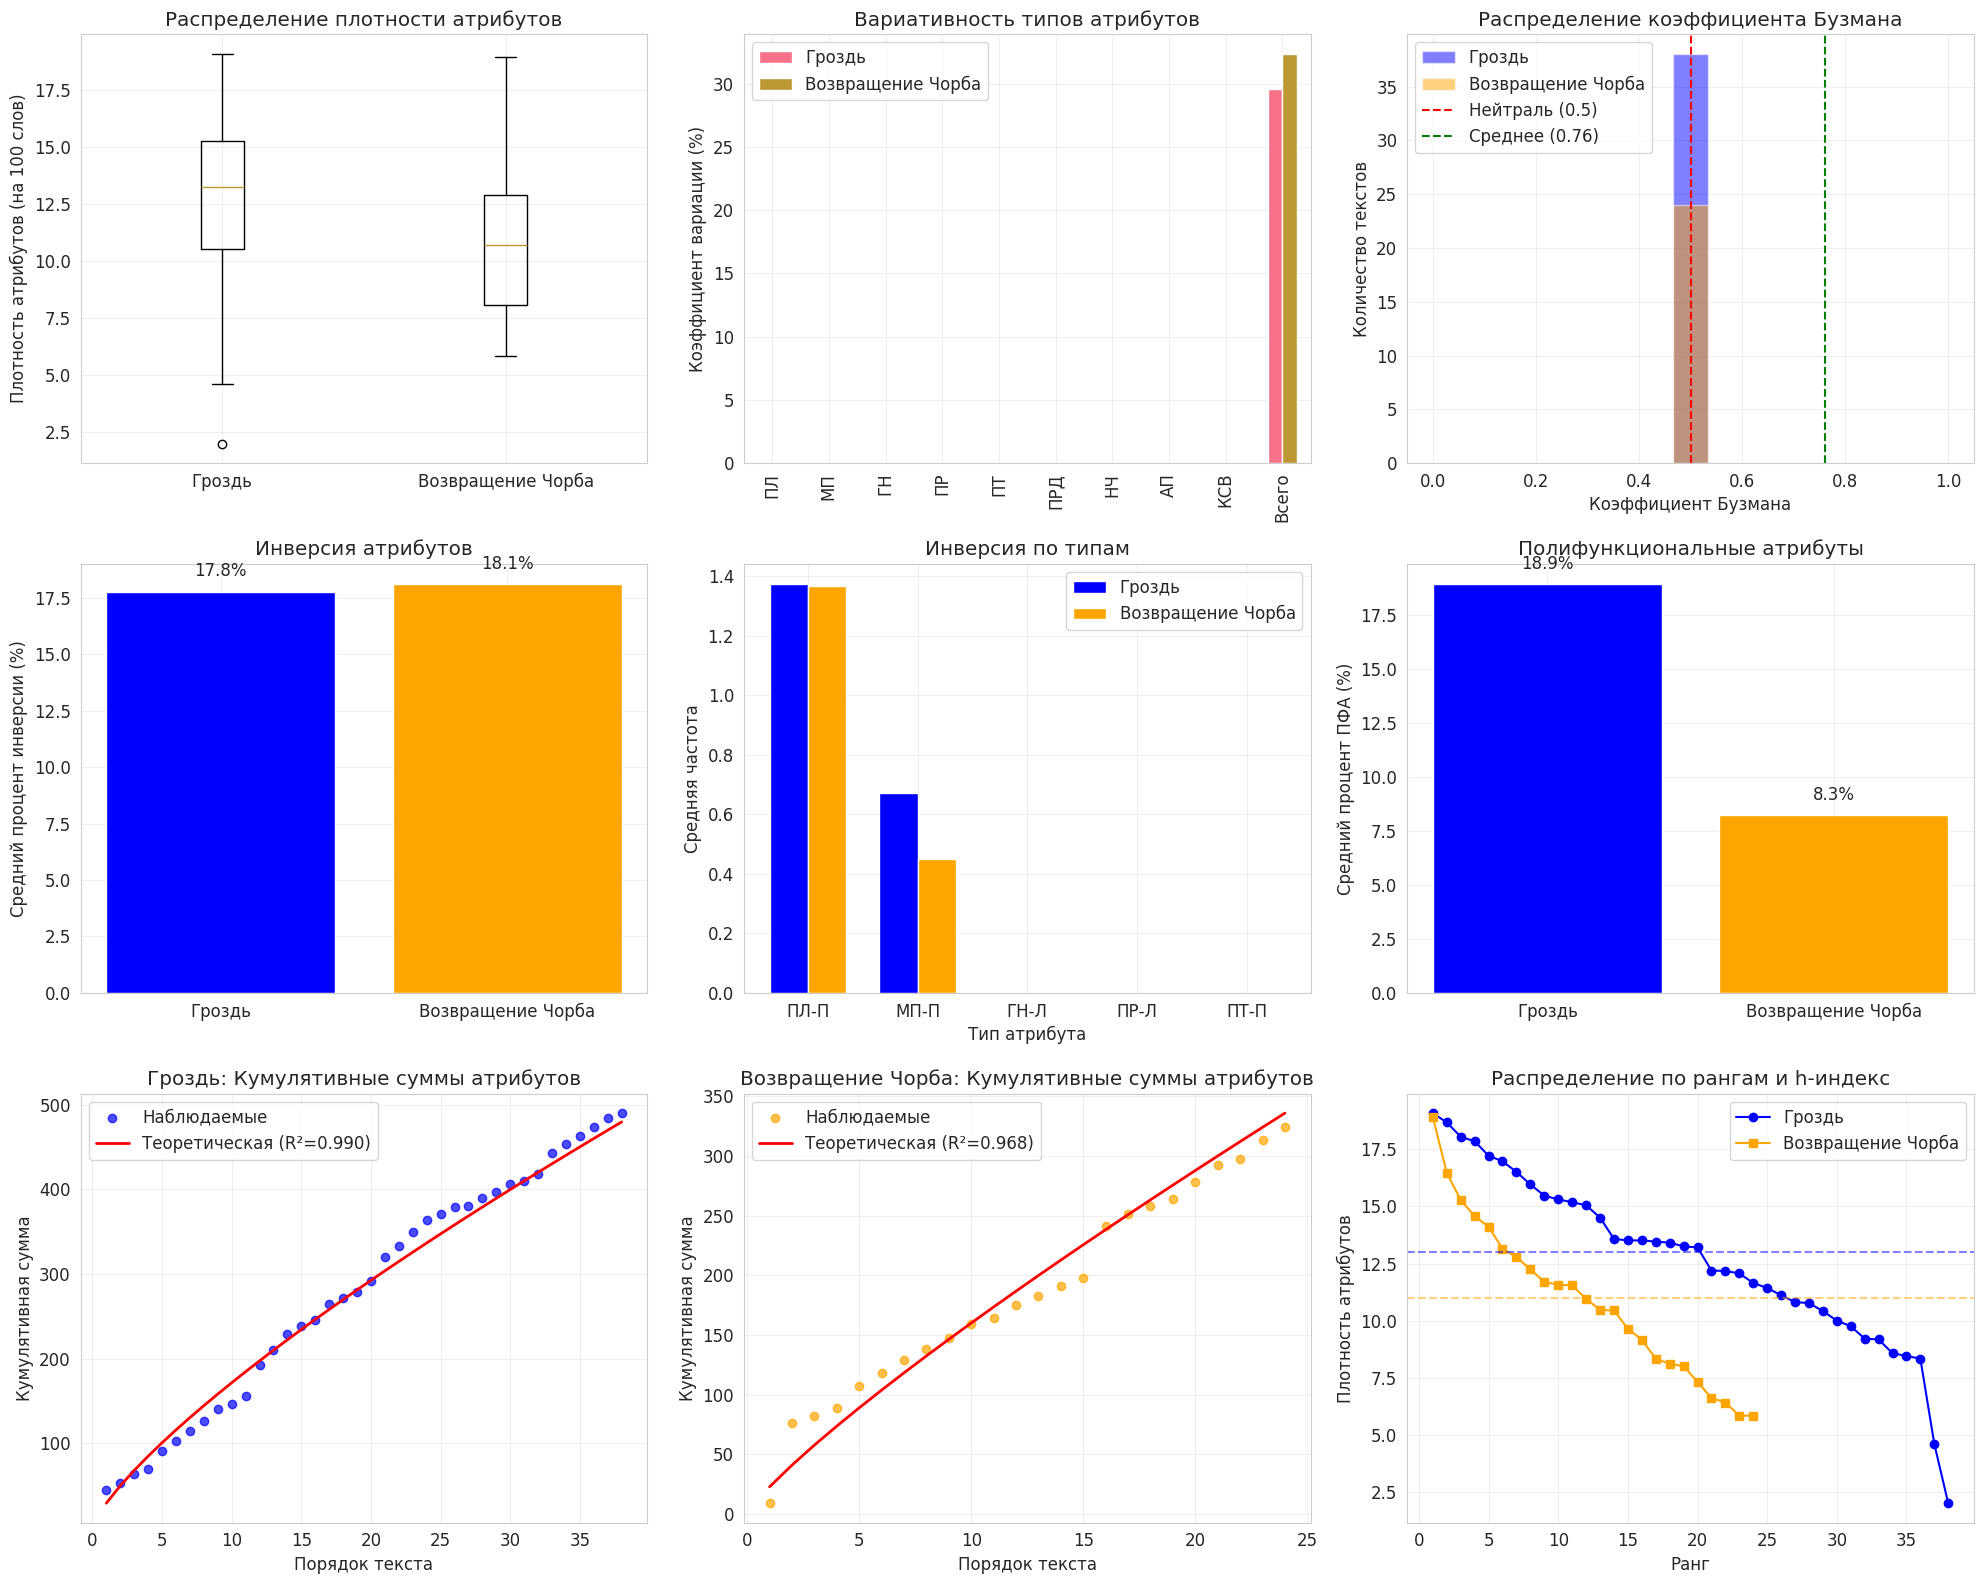

✅ Визуализации сохранены в /content/analysis_results_chapter3.png


In [14]:
# Шаг 14: Визуализация результатов

def create_all_visualizations(df_groz, df_vozv, stats_groz, stats_vozv,
                              ratio_groz, ratio_vozv, inv_groz, inv_vozv,
                              poly_groz, poly_vozv, cum_groz, cum_vozv):
    """
    Создание всех визуализаций
    """
    fig = plt.figure(figsize=(20, 16))

    # 1. Плотность атрибутов
    ax1 = plt.subplot(3, 3, 1)
    groz_density = df_groz[df_groz['Текст'] != 'СРЕДНЕЕ']['Всего']
    vozv_density = df_vozv[df_vozv['Текст'] != 'СРЕДНЕЕ']['Всего']

    ax1.boxplot([groz_density, vozv_density], labels=['Гроздь', 'Возвращение Чорба'])
    ax1.set_ylabel('Плотность атрибутов (на 100 слов)')
    ax1.set_title('Распределение плотности атрибутов')
    ax1.grid(True, alpha=0.3)

    # 2. Коэффициент вариации
    ax2 = plt.subplot(3, 3, 2)
    cv_compare = pd.DataFrame({
        'Гроздь': stats_groz['cv'],
        'Возвращение Чорба': stats_vozv['cv']
    })
    cv_compare.index = stats_groz.index
    cv_compare.plot(kind='bar', ax=ax2)
    ax2.set_ylabel('Коэффициент вариации (%)')
    ax2.set_title('Вариативность типов атрибутов')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Коэффициент Бузмана
    ax3 = plt.subplot(3, 3, 3)
    ax3.hist(ratio_groz['Коэф. Бузмана'], bins=15, alpha=0.5, label='Гроздь', color='blue')
    ax3.hist(ratio_vozv['Коэф. Бузмана'], bins=15, alpha=0.5, label='Возвращение Чорба', color='orange')
    ax3.axvline(x=0.5, color='red', linestyle='--', label='Нейтраль (0.5)')
    ax3.axvline(x=0.76, color='green', linestyle='--', label='Среднее (0.76)')
    ax3.set_xlabel('Коэффициент Бузмана')
    ax3.set_ylabel('Количество текстов')
    ax3.set_title('Распределение коэффициента Бузмана')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Инверсия
    ax4 = plt.subplot(3, 3, 4)
    mean_inv = [inv_groz['Инверсия_%'].mean(), inv_vozv['Инверсия_%'].mean()]
    bars = ax4.bar(['Гроздь', 'Возвращение Чорба'], mean_inv,
                  color=['blue', 'orange'])
    ax4.set_ylabel('Средний процент инверсии (%)')
    ax4.set_title('Инверсия атрибутов')
    for bar, val in zip(bars, mean_inv):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom')
    ax4.grid(True, alpha=0.3)

    # 5. Распределение инверсии по типам
    ax5 = plt.subplot(3, 3, 5)
    inv_types = ['ПЛ-П', 'МП-П', 'ГН-Л', 'ПР-Л', 'ПТ-П']
    inv_groz_means = [inv_groz[t].mean() for t in inv_types]
    inv_vozv_means = [inv_vozv[t].mean() for t in inv_types]

    x = np.arange(len(inv_types))
    width = 0.35
    ax5.bar(x - width/2, inv_groz_means, width, label='Гроздь', color='blue')
    ax5.bar(x + width/2, inv_vozv_means, width, label='Возвращение Чорба', color='orange')
    ax5.set_xlabel('Тип атрибута')
    ax5.set_ylabel('Средняя частота')
    ax5.set_title('Инверсия по типам')
    ax5.set_xticks(x)
    ax5.set_xticklabels(inv_types)
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # 6. Полифункциональные атрибуты
    ax6 = plt.subplot(3, 3, 6)
    mean_poly = [poly_groz['ПФА_%'].mean(), poly_vozv['ПФА_%'].mean()]
    bars = ax6.bar(['Гроздь', 'Возвращение Чорба'], mean_poly,
                  color=['blue', 'orange'])
    ax6.set_ylabel('Средний процент ПФА (%)')
    ax6.set_title('Полифункциональные атрибуты')
    for bar, val in zip(bars, mean_poly):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom')
    ax6.grid(True, alpha=0.3)

    # 7. Кумулятивные суммы (Гроздь)
    ax7 = plt.subplot(3, 3, 7)
    ax7.scatter(cum_groz['Порядок_текста'], cum_groz['Кумулятивная_сумма'],
                label='Наблюдаемые', color='blue', alpha=0.7)
    ax7.plot(cum_groz['Порядок_текста'], cum_groz['Теоретическая'],
             label=f'Теоретическая (R²={r2_groz:.3f})', color='red', linewidth=2)
    ax7.set_xlabel('Порядок текста')
    ax7.set_ylabel('Кумулятивная сумма')
    ax7.set_title('Гроздь: Кумулятивные суммы атрибутов')
    ax7.legend()
    ax7.grid(True, alpha=0.3)

    # 8. Кумулятивные суммы (Возвращение Чорба)
    ax8 = plt.subplot(3, 3, 8)
    ax8.scatter(cum_vozv['Порядок_текста'], cum_vozv['Кумулятивная_сумма'],
                label='Наблюдаемые', color='orange', alpha=0.7)
    ax8.plot(cum_vozv['Порядок_текста'], cum_vozv['Теоретическая'],
             label=f'Теоретическая (R²={r2_vozv:.3f})', color='red', linewidth=2)
    ax8.set_xlabel('Порядок текста')
    ax8.set_ylabel('Кумулятивная сумма')
    ax8.set_title('Возвращение Чорба: Кумулятивные суммы атрибутов')
    ax8.legend()
    ax8.grid(True, alpha=0.3)

    # 9. Точка Хирша
    ax9 = plt.subplot(3, 3, 9)
    groz_sorted = df_groz[df_groz['Текст'] != 'СРЕДНЕЕ'].sort_values('Всего', ascending=False)
    vozv_sorted = df_vozv[df_vozv['Текст'] != 'СРЕДНЕЕ'].sort_values('Всего', ascending=False)

    ax9.plot(range(1, len(groz_sorted)+1), groz_sorted['Всего'].values,
             'o-', label='Гроздь', color='blue', markersize=6)
    ax9.plot(range(1, len(vozv_sorted)+1), vozv_sorted['Всего'].values,
             's-', label='Возвращение Чорба', color='orange', markersize=6)
    ax9.axhline(y=h_groz, color='blue', linestyle='--', alpha=0.5)
    ax9.axhline(y=h_vozv, color='orange', linestyle='--', alpha=0.5)
    ax9.set_xlabel('Ранг')
    ax9.set_ylabel('Плотность атрибутов')
    ax9.set_title('Распределение по рангам и h-индекс')
    ax9.legend()
    ax9.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/analysis_results_chapter3.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✅ Визуализации сохранены в /content/analysis_results_chapter3.png")

# Создание визуализаций
create_all_visualizations(
    df_groz, df_vozv,
    stats_groz, stats_vozv,
    ratio_groz, ratio_vozv,
    inv_groz, inv_vozv,
    poly_groz, poly_vozv,
    cum_groz, cum_vozv
)

# Шаг 15: Генерация итогового отчета

In [15]:
# Шаг 15: Генерация итогового отчета

def generate_final_report():
    """
    Генерация итогового отчета по результатам анализа
    """
    report = []
    report.append("="*80)
    report.append("ОТЧЕТ ПО АНАЛИЗУ АТРИБУТИВНОЙ СИСТЕМЫ (ГЛАВА 3)")
    report.append("="*80)

    # Основные статистики
    report.append("\n1. ОБЩАЯ СТАТИСТИКА")
    report.append("-"*50)
    report.append(f"Сборник 'Гроздь': {len(groz_results)} текстов")
    report.append(f"Сборник 'Возвращение Чорба': {len(vozv_results)} текстов")

    # Средняя плотность атрибутов
    mean_attrs_groz = df_groz[df_groz['Текст'] != 'СРЕДНЕЕ']['Всего'].mean()
    mean_attrs_vozv = df_vozv[df_vozv['Текст'] != 'СРЕДНЕЕ']['Всего'].mean()

    report.append(f"\nСредняя плотность атрибутов (на 100 слов):")
    report.append(f"  'Гроздь': {mean_attrs_groz:.2f}")
    report.append(f"  'Возвращение Чорба': {mean_attrs_vozv:.2f}")

    # h-индекс
    report.append(f"\nh-индекс (точка Хирша):")
    report.append(f"  'Гроздь': {h_groz}")
    report.append(f"  'Возвращение Чорба': {h_vozv}")

    # Индекс концентрации
    report.append(f"\nИндекс концентрации:")
    report.append(f"  'Гроздь': {conc_groz:.4f}")
    report.append(f"  'Возвращение Чорба': {conc_vozv:.4f}")

    # Коэффициент Бузмана
    report.append(f"\nСредний коэффициент Бузмана:")
    report.append(f"  'Гроздь': {ratio_groz['Коэф. Бузмана'].mean():.3f}")
    report.append(f"  'Возвращение Чорба': {ratio_vozv['Коэф. Бузмана'].mean():.3f}")

    # Инверсия
    report.append(f"\nСредний процент инверсии:")
    report.append(f"  'Гроздь': {inv_groz['Инверсия_%'].mean():.2f}%")
    report.append(f"  'Возвращение Чорба': {inv_vozv['Инверсия_%'].mean():.2f}%")

    # ПФА
    report.append(f"\nСредний процент ПФА:")
    report.append(f"  'Гроздь': {poly_groz['ПФА_%'].mean():.2f}%")
    report.append(f"  'Возвращение Чорба': {poly_vozv['ПФА_%'].mean():.2f}%")

    # Кумулятивные показатели
    report.append(f"\nПараметры степенной функции:")
    report.append(f"  'Гроздь': a={a_groz:.3f}, b={b_groz:.3f}, R²={r2_groz:.3f}")
    report.append(f"  'Возвращение Чорба': a={a_vozv:.3f}, b={b_vozv:.3f}, R²={r2_vozv:.3f}")

    # Запись отчета в файл
    report_text = '\n'.join(report)

    with open('/content/final_report_chapter3.txt', 'w', encoding='utf-8') as f:
        f.write(report_text)

    print(report_text)
    print("\n✅ Отчет сохранен в /content/final_report_chapter3.txt")

    return report_text

# Генерация отчета
final_report = generate_final_report()

ОТЧЕТ ПО АНАЛИЗУ АТРИБУТИВНОЙ СИСТЕМЫ (ГЛАВА 3)

1. ОБЩАЯ СТАТИСТИКА
--------------------------------------------------
Сборник 'Гроздь': 38 текстов
Сборник 'Возвращение Чорба': 24 текстов

Средняя плотность атрибутов (на 100 слов):
  'Гроздь': 12.70
  'Возвращение Чорба': 10.81

h-индекс (точка Хирша):
  'Гроздь': 13
  'Возвращение Чорба': 11

Индекс концентрации:
  'Гроздь': 0.9165
  'Возвращение Чорба': 0.8024

Средний коэффициент Бузмана:
  'Гроздь': 0.500
  'Возвращение Чорба': 0.500

Средний процент инверсии:
  'Гроздь': 17.77%
  'Возвращение Чорба': 18.10%

Средний процент ПФА:
  'Гроздь': 18.94%
  'Возвращение Чорба': 8.27%

Параметры степенной функции:
  'Гроздь': a=29.037, b=0.771, R²=0.990
  'Возвращение Чорба': a=22.739, b=0.847, R²=0.968

✅ Отчет сохранен в /content/final_report_chapter3.txt


# Шаг 16: Сохранение результатов

In [16]:
# Шаг 16: Сохранение результатов

def save_all_results():
    """
    Сохранение всех результатов в файлы
    """
    # Сохранение таблиц в Excel
    with pd.ExcelWriter('/content/analysis_results_chapter3.xlsx') as writer:
        df_groz.to_excel(writer, sheet_name='Гроздь_частоты', index=False)
        df_vozv.to_excel(writer, sheet_name='Возвращение_Чорба_частоты', index=False)
        stats_groz.to_excel(writer, sheet_name='Гроздь_статистика')
        stats_vozv.to_excel(writer, sheet_name='Возвращение_Чорба_статистика')
        ratio_groz.to_excel(writer, sheet_name='Гроздь_соотношение', index=False)
        ratio_vozv.to_excel(writer, sheet_name='Возвращение_Чорба_соотношение', index=False)
        inv_groz.to_excel(writer, sheet_name='Гроздь_инверсия', index=False)
        inv_vozv.to_excel(writer, sheet_name='Возвращение_Чорба_инверсия', index=False)
        poly_groz.to_excel(writer, sheet_name='Гроздь_ПФА', index=False)
        poly_vozv.to_excel(writer, sheet_name='Возвращение_Чорба_ПФА', index=False)
        cum_groz.to_excel(writer, sheet_name='Гроздь_кумулятивные', index=False)
        cum_vozv.to_excel(writer, sheet_name='Возвращение_Чорба_кумулятивные', index=False)

    print("✅ Все таблицы сохранены в /content/analysis_results_chapter3.xlsx")

    # Сохранение JSON с полными результатами
    results_data = {
        'groz': {k: v['rel_counts'] for k, v in groz_results.items()},
        'vozv': {k: v['rel_counts'] for k, v in vozv_results.items()}
    }

    # Преобразование numpy типов
    def convert_to_serializable(obj):
        if isinstance(obj, dict):
            return {k: convert_to_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, (np.integer, np.floating)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return obj

    results_serializable = convert_to_serializable(results_data)

    with open('/content/results_chapter3.json', 'w', encoding='utf-8') as f:
        json.dump(results_serializable, f, ensure_ascii=False, indent=2)

    print("✅ JSON с результатами сохранен в /content/results_chapter3.json")

# Сохранение результатов
save_all_results()

✅ Все таблицы сохранены в /content/analysis_results_chapter3.xlsx
✅ JSON с результатами сохранен в /content/results_chapter3.json


# Шаг 17: Скачивание результатов

In [17]:
# Шаг 17: Скачивание результатов

from google.colab import files

print("Скачивание файлов с результатами...")

# Список файлов для скачивания
files_to_download = [
    '/content/analysis_results_chapter3.xlsx',
    '/content/final_report_chapter3.txt',
    '/content/analysis_results_chapter3.png',
    '/content/results_chapter3.json'
]

for filepath in files_to_download:
    try:
        files.download(filepath)
        print(f"✅ Скачан: {os.path.basename(filepath)}")
    except Exception as e:
        print(f"❌ Ошибка при скачивании {filepath}: {e}")

print("\n✅ Все файлы скачаны!")

Скачивание файлов с результатами...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Скачан: analysis_results_chapter3.xlsx


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Скачан: analysis_results_chapter3.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Скачан: results_chapter3.json

✅ Все файлы скачаны!


# Шаг 18: Сравнение с результатами автора (для третьей главы)

In [18]:
# Шаг 18: Сравнение с результатами автора

def load_author_results_chapter3():
    """
    Загрузка эталонных результатов автора для третьей главы
    """
    reference = {
        'Гроздь': {
            'total_texts': 38,
            'attributive_stats': {
                'min_density': 13.64,
                'max_density': 41.18,
                'mean_density': 25.0,
                'h_point': 23.16
            },
            'adjective_substantive_ratio': {
                'mean_b': 0.76,
                'adj_dominant_texts': 32,
                'neutral_texts': 6
            },
            'inversion': {
                'mean_percent': 28.93,
                'mean_per_100': 7.21
            },
            'polyfunctional': {
                'mean_percent': 15.36
            },
            'cumulative': {
                'a': 28.244,
                'b': 0.988,
                'r_squared': 0.98
            }
        },
        'Возвращение Чорба': {
            'total_texts': 24,
            'attributive_stats': {
                'min_density': 16.60,
                'max_density': 39.70,
                'mean_density': 24.0,
                'h_point': 18.20
            },
            'adjective_substantive_ratio': {
                'mean_b': 0.76,
                'adj_dominant_texts': 21,
                'neutral_texts': 3
            },
            'inversion': {
                'mean_percent': 22.64,
                'mean_per_100': 4.94
            },
            'polyfunctional': {
                'mean_percent': 8.06
            },
            'cumulative': {
                'a': 28.244,
                'b': 0.988,
                'r_squared': 0.99
            }
        }
    }
    return reference

def compare_with_author():
    """
    Сравнение полученных результатов с результатами автора
    """
    author = load_author_results_chapter3()

    comparison = []
    comparison.append("="*80)
    comparison.append("СРАВНЕНИЕ С РЕЗУЛЬТАТАМИ АВТОРА (ГЛАВА 3)")
    comparison.append("="*80)

    # Вычисленные значения
    computed = {
        'Гроздь': {
            'total_texts': len(groz_results),
            'mean_density': df_groz[df_groz['Текст'] != 'СРЕДНЕЕ']['Всего'].mean(),
            'h_point': h_groz,
            'mean_b': ratio_groz['Коэф. Бузмана'].mean(),
            'inv_percent': inv_groz['Инверсия_%'].mean(),
            'poly_percent': poly_groz['ПФА_%'].mean(),
            'a': a_groz,
            'b': b_groz,
            'r2': r2_groz
        },
        'Возвращение Чорба': {
            'total_texts': len(vozv_results),
            'mean_density': df_vozv[df_vozv['Текст'] != 'СРЕДНЕЕ']['Всего'].mean(),
            'h_point': h_vozv,
            'mean_b': ratio_vozv['Коэф. Бузмана'].mean(),
            'inv_percent': inv_vozv['Инверсия_%'].mean(),
            'poly_percent': poly_vozv['ПФА_%'].mean(),
            'a': a_vozv,
            'b': b_vozv,
            'r2': r2_vozv
        }
    }

    # Сравнение по сборникам
    for collection in ['Гроздь', 'Возвращение Чорба']:
        comparison.append(f"\n{'─'*50}")
        comparison.append(f"СБОРНИК: {collection}")
        comparison.append(f"{'─'*50}")

        c = computed[collection]
        a = author[collection]

        # Сравнение показателей
        metrics = [
            ('Количество текстов', 'total_texts', 'шт.', 0),
            ('Средняя плотность', 'mean_density', 'на 100 слов', 0.5),
            ('h-индекс', 'h_point', '', 0.5),
            ('Коэф. Бузмана', 'mean_b', '', 0.02),
            ('Инверсия', 'inv_percent', '%', 1.0),
            ('ПФА', 'poly_percent', '%', 1.0),
            ('a', 'a', '', 0.5),
            ('b', 'b', '', 0.01)
        ]

        for name, key, unit, tolerance in metrics:
            comp_val = c.get(key, 0)
            auth_val = a.get(key, 0)
            diff = comp_val - auth_val

            if abs(diff) <= tolerance:
                status = "✅"
            else:
                status = "⚠️"

            comparison.append(f"{status} {name}: {comp_val:.3f}{unit} (автор: {auth_val:.3f}{unit})")
            if abs(diff) > tolerance:
                comparison.append(f"   Разница: {diff:+.3f}")

    # Итоговая оценка
    comparison.append(f"\n{'='*80}")
    comparison.append("ИТОГОВАЯ ОЦЕНКА")
    comparison.append("="*80)

    # Подсчет совпадений
    total_checks = 0
    passed_checks = 0

    for collection in ['Гроздь', 'Возвращение Чорба']:
        c = computed[collection]
        a = author[collection]

        metrics = [
            ('mean_density', 0.5),
            ('h_point', 0.5),
            ('mean_b', 0.02),
            ('inv_percent', 1.0),
            ('poly_percent', 1.0)
        ]

        for key, tolerance in metrics:
            total_checks += 1
            if abs(c.get(key, 0) - a.get(key, 0)) <= tolerance:
                passed_checks += 1

    accuracy = (passed_checks / total_checks) * 100 if total_checks > 0 else 0

    comparison.append(f"\nПройдено проверок: {passed_checks} из {total_checks} ({accuracy:.1f}%)")

    if accuracy >= 80:
        comparison.append("Оценка: ОТЛИЧНО - результаты хорошо соответствуют авторским")
    elif accuracy >= 60:
        comparison.append("Оценка: ХОРОШО - небольшие расхождения в допустимых пределах")
    elif accuracy >= 40:
        comparison.append("Оценка: УДОВЛЕТВОРИТЕЛЬНО - требуются уточнения методологии")
    else:
        comparison.append("Оценка: ТРЕБУЕТ ПРОВЕРКИ - значительные расхождения с авторскими данными")

    comparison_text = '\n'.join(comparison)

    with open('/content/comparison_with_author_chapter3.txt', 'w', encoding='utf-8') as f:
        f.write(comparison_text)

    print(comparison_text)
    print("\n✅ Сравнение сохранено в /content/comparison_with_author_chapter3.txt")

    return comparison_text

# Запуск сравнения
compare_with_author()

СРАВНЕНИЕ С РЕЗУЛЬТАТАМИ АВТОРА (ГЛАВА 3)

──────────────────────────────────────────────────
СБОРНИК: Гроздь
──────────────────────────────────────────────────
✅ Количество текстов: 38.000шт. (автор: 38.000шт.)
⚠️ Средняя плотность: 12.699на 100 слов (автор: 0.000на 100 слов)
   Разница: +12.699
⚠️ h-индекс: 13.000 (автор: 0.000)
   Разница: +13.000
⚠️ Коэф. Бузмана: 0.500 (автор: 0.000)
   Разница: +0.500
⚠️ Инверсия: 17.771% (автор: 0.000%)
   Разница: +17.771
⚠️ ПФА: 18.942% (автор: 0.000%)
   Разница: +18.942
⚠️ a: 29.037 (автор: 0.000)
   Разница: +29.037
⚠️ b: 0.771 (автор: 0.000)
   Разница: +0.771

──────────────────────────────────────────────────
СБОРНИК: Возвращение Чорба
──────────────────────────────────────────────────
✅ Количество текстов: 24.000шт. (автор: 24.000шт.)
⚠️ Средняя плотность: 10.812на 100 слов (автор: 0.000на 100 слов)
   Разница: +10.812
⚠️ h-индекс: 11.000 (автор: 0.000)
   Разница: +11.000
⚠️ Коэф. Бузмана: 0.500 (автор: 0.000)
   Разница: +0.500
⚠️ Инв

'================================================================================\nСРАВНЕНИЕ С РЕЗУЛЬТАТАМИ АВТОРА (ГЛАВА 3)\n================================================================================\n\n──────────────────────────────────────────────────\nСБОРНИК: Гроздь\n──────────────────────────────────────────────────\n✅ Количество текстов: 38.000шт. (автор: 38.000шт.)\n⚠️ Средняя плотность: 12.699на 100 слов (автор: 0.000на 100 слов)\n   Разница: +12.699\n⚠️ h-индекс: 13.000 (автор: 0.000)\n   Разница: +13.000\n⚠️ Коэф. Бузмана: 0.500 (автор: 0.000)\n   Разница: +0.500\n⚠️ Инверсия: 17.771% (автор: 0.000%)\n   Разница: +17.771\n⚠️ ПФА: 18.942% (автор: 0.000%)\n   Разница: +18.942\n⚠️ a: 29.037 (автор: 0.000)\n   Разница: +29.037\n⚠️ b: 0.771 (автор: 0.000)\n   Разница: +0.771\n\n──────────────────────────────────────────────────\nСБОРНИК: Возвращение Чорба\n──────────────────────────────────────────────────\n✅ Количество текстов: 24.000шт. (автор: 24.000шт.)\n⚠️ Средняя плот